In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from utils import DATA_DIR, ROOT_DIR
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts'))
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts/scaling'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from dataloader import get_nd_array, get_slice
from download.weka import pull_predictions_from_weka
from download.hf import pull_predictions_from_hf

import ladder
plt.close()

In [3]:
local_path = pull_predictions_from_hf("allenai/ladder-evals", "benchmarks")

In [4]:
df = pd.read_parquet(local_path)
print(f'Loaded {len(df):,} model evaluations')

Loaded 100,000 model evaluations


In [5]:
def task_tag(task_name):
    return task_name.split("::")[0].replace(":rc", "") if "::" in task_name else task_name

MODELS = list(df['model'].unique())
MIXES = list(df['mix'].unique())
STEPS = list(df['step'].unique())
TASKS = sorted(list(df['task'].unique()))

In [6]:
from ladder import sort_experiment_names
from utils.constants_models import MODEL_LIST_MIXES

# Train models
all_ladder_models = [model for model in MODELS if 'peteish-moreeval' in model]
all_ladder_models = sort_experiment_names(all_ladder_models)

# Ladder config
ladder_config_path = f'{ROOT_DIR}/analysis/utils/ladder_config.json'

# Eval models
MODEL_LIST_MIXES = [model.split("/")[-1] for model in MODEL_LIST_MIXES]
BROKEN_MODELS = ["gemma-2b", "gemma-7b", "gemma-2-2b", "gemma-2-9b"] # gemma models broken in oe-eval
LLAMA_3_MODELS = [model for model in MODELS if 'Llama-3' in model]

all_models = sorted([model for model in MODELS if model not in MODEL_LIST_MIXES + BROKEN_MODELS + all_ladder_models])

### Select Tasks

In [7]:
selected_tasks = [
    t
    for t in TASKS
    if ":" not in t 
    and "bbh" not in t and "paloma" not in t and "llm_compression" not in t 
    and "custom_loss" not in t and "coqa" not in t and "deepmind" not in t
]

selected_tasks += [
    t
    for t in TASKS
    if ":mc" in t
    and "bbh" not in t and "paloma" not in t and "llm_compression" not in t
    and "custom_loss" not in t and "coqa" not in t and "deepmind" not in t
]

mmlu      = [t for t in TASKS if 'mmlu' in t and ':' not in t and '_pro_' not in t]
minerva   = [t for t in TASKS if 'minerva' in t and ':' not in t]
mmlu_pro  = [t for t in TASKS if '_pro_' in t and ':rc' in t]
mmlu_mc   = [t for t in TASKS if 'mmlu' in t and ':mc' in t and '_pro_' not in t]
olmes     = ['arc_challenge', 'arc_easy', 'boolq', 'csqa', 'hellaswag', 'openbookqa', 'piqa', 'socialiqa', 'winogrande']
olmes_mc  = [f'{task}:mc' for task in olmes]
olmes_para        = [f'{task}:para' for task in olmes]
olmes_distractors = [f'{task}:distractors' for task in olmes]
olmes_enlarge     = [f'{task}:enlarge' for task in olmes]
olmes_gen = ['drop', 'gsm8k', 'jeopardy', 'naturalqs', 'squad', 'triviaqa']
agi_eval  = [t for t in TASKS if 'agi_eval' in t and ':' not in t]
bbh       = [t for t in TASKS if 'bbh' in t and ':' not in t]
paloma    = [t for t in TASKS if 'paloma' in t]
llm_compression = [t for t in TASKS if 'llm_compression' in t]
custom_loss = [t for t in TASKS if 'custom_loss' in t]

selected_tasks = olmes + olmes_gen + [olmes, olmes_para, olmes_distractors, olmes_enlarge, mmlu, olmes_mc, mmlu_mc, olmes_gen, minerva]
selected_tasks += ['gsm_symbolic_main', mmlu_pro, 'autobencher', 'autobencher:mc']
selected_tasks += ['minerva_math_500', 'mbpp', 'mbppplus', 'codex_humaneval', 'codex_humanevalplus', 'copycolors:mc']

# selected_tasks = olmes + olmes_para + olmes_distractors + olmes_enlarge

def get_title_from_task(task):
    if isinstance(task, list):
        title_mapping = {
            'mmlu_pro_': 'mmlu_pro',
            'mmlu_abstract_algebra:mc': 'mmlu_mc',
            'mmlu': 'mmlu',
            'minerva': 'minerva',
            'agi_eval': 'agi_eval',
            'bbh': 'bbh',
            'arc_challenge:para': 'olmes_core9_para',
            'arc_challenge:distractors': 'olmes_core9_distractors',
            'arc_challenge:enlarge': 'olmes_core9_enlarge',
            'arc_challenge:mc': 'olmes_core9_mc',
            'arc_challenge': 'olmes_core9',
            'drop': 'olmes_gen',
        }
        for key, title in title_mapping.items():
            if key in task[0]:
                return title
        return 'aggregate'
    return task

def set_title_from_task(ax, task):
    ax.set_title(get_title_from_task(task))

### Meta-evaluate Benchmarks

In [8]:
from ladder import run_ladder

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)  # ignore fitting warnings

In [9]:
from ladder import run_ladder
from stats import compute_significance, compute_total_variation
from table import display_task_variants

In [10]:
# tv, _ = compute_total_variation(
#     df, models=['peteish-moreeval-1B-5xC'], metric='primary_score', tasks=[selected_tasks[0]]
# )

# get_nd_array(df, ['step', 'task'], 'primary_score', model='peteish-moreeval-1B-5xC', task=['gsm8k', 'arc_challenge'])

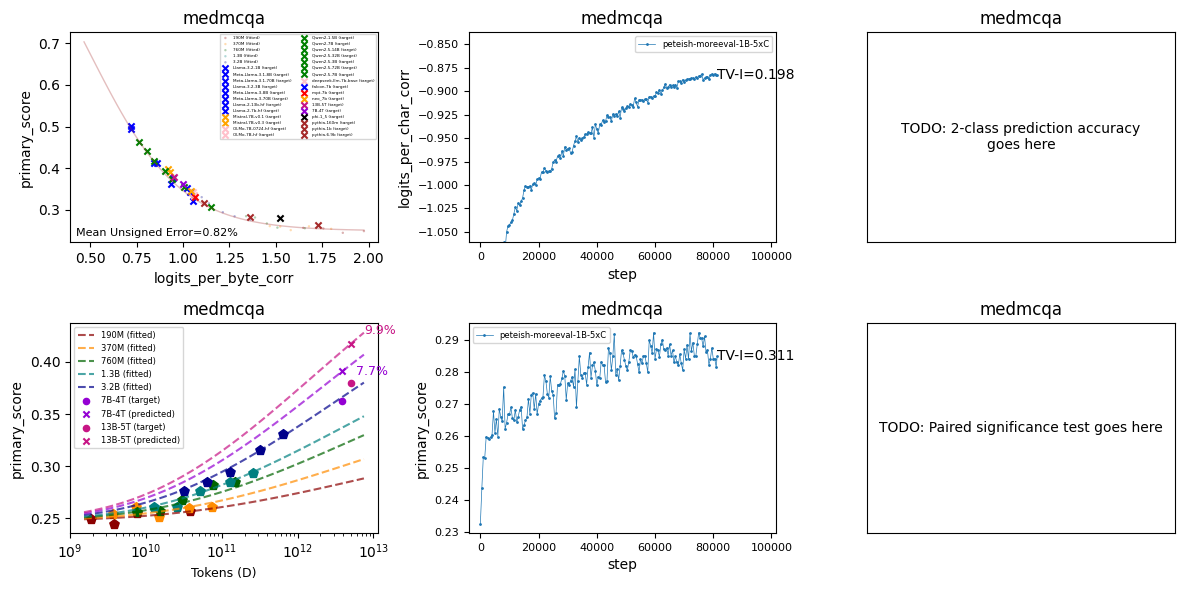

In [11]:
def run_analysis(task, metric='primary_score', axes=None):
    try:
        ax = [axes[1, 0]] if axes is not None else None
        _, _, rel_error_stacked = run_ladder(
            df,
            task,
            train_models=[m for m in all_ladder_models if '190M-5xC' not in m],
            eval_models=["peteish7", "peteish13-highlr"],
            config_path=ladder_config_path,
            run_step1=False, run_step2=False,
            axes=ax
        )
        if ax:
            ax[0].set_ylabel(metric)
            ax[0].legend(fontsize=6)
        rel_error_stacked = rel_error_stacked[0] # keep 7B-5T

        # TODO: Add MSE vs. external models on step 2 prediction here
        ax = [axes[0, 0]] if axes is not None else None
        _, mse_step_2 = run_ladder(
            df,
            task,
            train_models=[m for m in all_ladder_models if '190M-5xC' not in m] + LLAMA_3_MODELS,
            # eval_models=["peteish7", "peteish13-highlr"],
            # eval_models=all_models,
            eval_models=[m for m in all_models if 'OLMo-7B-0424-hf' not in m],
            config_path=ladder_config_path,
            run_step1=False, run_stacked=False,
            return_mse=True,
            axes=ax
        )
        if ax:
            # ax[0].get_legend().remove()
            ax[0].legend(fontsize=3, ncols=2)
            ax[0].set_xlabel('logits_per_byte_corr')
            ax[0].set_ylabel(metric)
            ax[0].text(
                x=0.02, y=0.02, s=f'Mean Unsigned Error={mse_step_2*100:.2f}%',
                transform=ax[0].transAxes,
                va='bottom', ha='left',
                fontsize=8
            )
    except Exception as e:
        print(task, 'failed on ladder fits', e)
        rel_error_stacked, mse_step_2 = 0, 0

    # TODO: Add seperability here

    ax = [axes[0, 1]] if axes is not None else None
    tv, _ = compute_total_variation(
        df, models=['peteish-moreeval-1B-5xC'], metric='logits_per_char_corr', tasks=[task], axes=ax
    )
    tv_bpb = tv[task]['total_variation'] if not isinstance(task, list) else tv.loc['total_variation']['aggregate']
    if ax:
        ax[0].legend(fontsize=6)
        
        # Get the y-values from the current axis
        lines = ax[0].get_lines()
        if len(lines) > 0:
            y_data = lines[0].get_ydata()
            # Set top limit 10% above max y value
            y_max = np.max(y_data)
            # Get y-value 10% into the curve for bottom limit
            idx = int(len(y_data) * 0.1)
            y_20_percent = y_data[idx]
            if not (np.isnan(y_20_percent) or np.isnan(y_max) or np.isinf(y_20_percent) or np.isinf(y_max)):
                ax[0].set_ylim(bottom=y_20_percent, top=y_max * (0.95 if y_max < 0 else 1.05))

    ax = [axes[1, 1]] if axes is not None else None
    tv, _ = compute_total_variation(
        df, models=['peteish-moreeval-1B-5xC'], metric=metric, tasks=[task], axes=ax
    )
    tv_primary = tv[task]['total_variation'] if not isinstance(task, list) else tv.loc['total_variation']['aggregate']
    if ax:
        ax[0].legend(fontsize=6)

    # TODO: Add significance analysis in bottom right plot
    if axes is not None:
        axes[1, 2].text(0.5, 0.5, 'TODO: Paired significance test goes here', 
                       horizontalalignment='center',
                       verticalalignment='center',
                       transform=axes[1, 2].transAxes)
        axes[1, 2].set_xticks([])
        axes[1, 2].set_yticks([])
        axes[0, 2].text(0.5, 0.5, 'TODO: 2-class prediction accuracy\ngoes here', 
                       horizontalalignment='center',
                       verticalalignment='center',
                       transform=axes[0, 2].transAxes)
        axes[0, 2].set_xticks([])
        axes[0, 2].set_yticks([])

    if axes is not None:
        for ax in axes.flat:
            ax.set_ylabel(ax.get_ylabel(), fontsize=10)
            ax.set_title(get_title_from_task(task))

    # Example of num instances and num tokens
    try:
        task_as_list = [task] if isinstance(task, str) else task
        total_cost = 0
        for subtask in task_as_list:
            task_results = get_slice(df, task=subtask)
            num_instances = task_results['num_instances'].iloc[0]
            eval_cost = num_instances
            assert (task_results['num_instances'] == num_instances).all(), f"num_instances should be constant across task={subtask} for task_as_list={task_as_list}"
            # if 'extra_metrics' in task_results and task_results['extra_metrics'][0] is not None:
            #     extra_metrics = eval(task_results['extra_metrics'][0])
            #     if 'num_tokens' in extra_metrics: 
            #         num_tokens = extra_metrics['num_tokens']
            #         eval_cost *= num_tokens # est. cost = num tokens * num instances
            total_cost += eval_cost
    except Exception as e:
        print(e)
        total_cost = 0

    return mse_step_2, rel_error_stacked, tv_bpb, tv_primary, total_cost

N_COLS = 2
N_ROWS = 3
fig, axes = plt.subplots(N_COLS, N_ROWS, figsize=(4*N_ROWS, 3*N_COLS), squeeze=False)
result = run_analysis('medmcqa', axes=axes)
# result = run_analysis(selected_tasks[0], axes=axes[0])
fig.tight_layout()

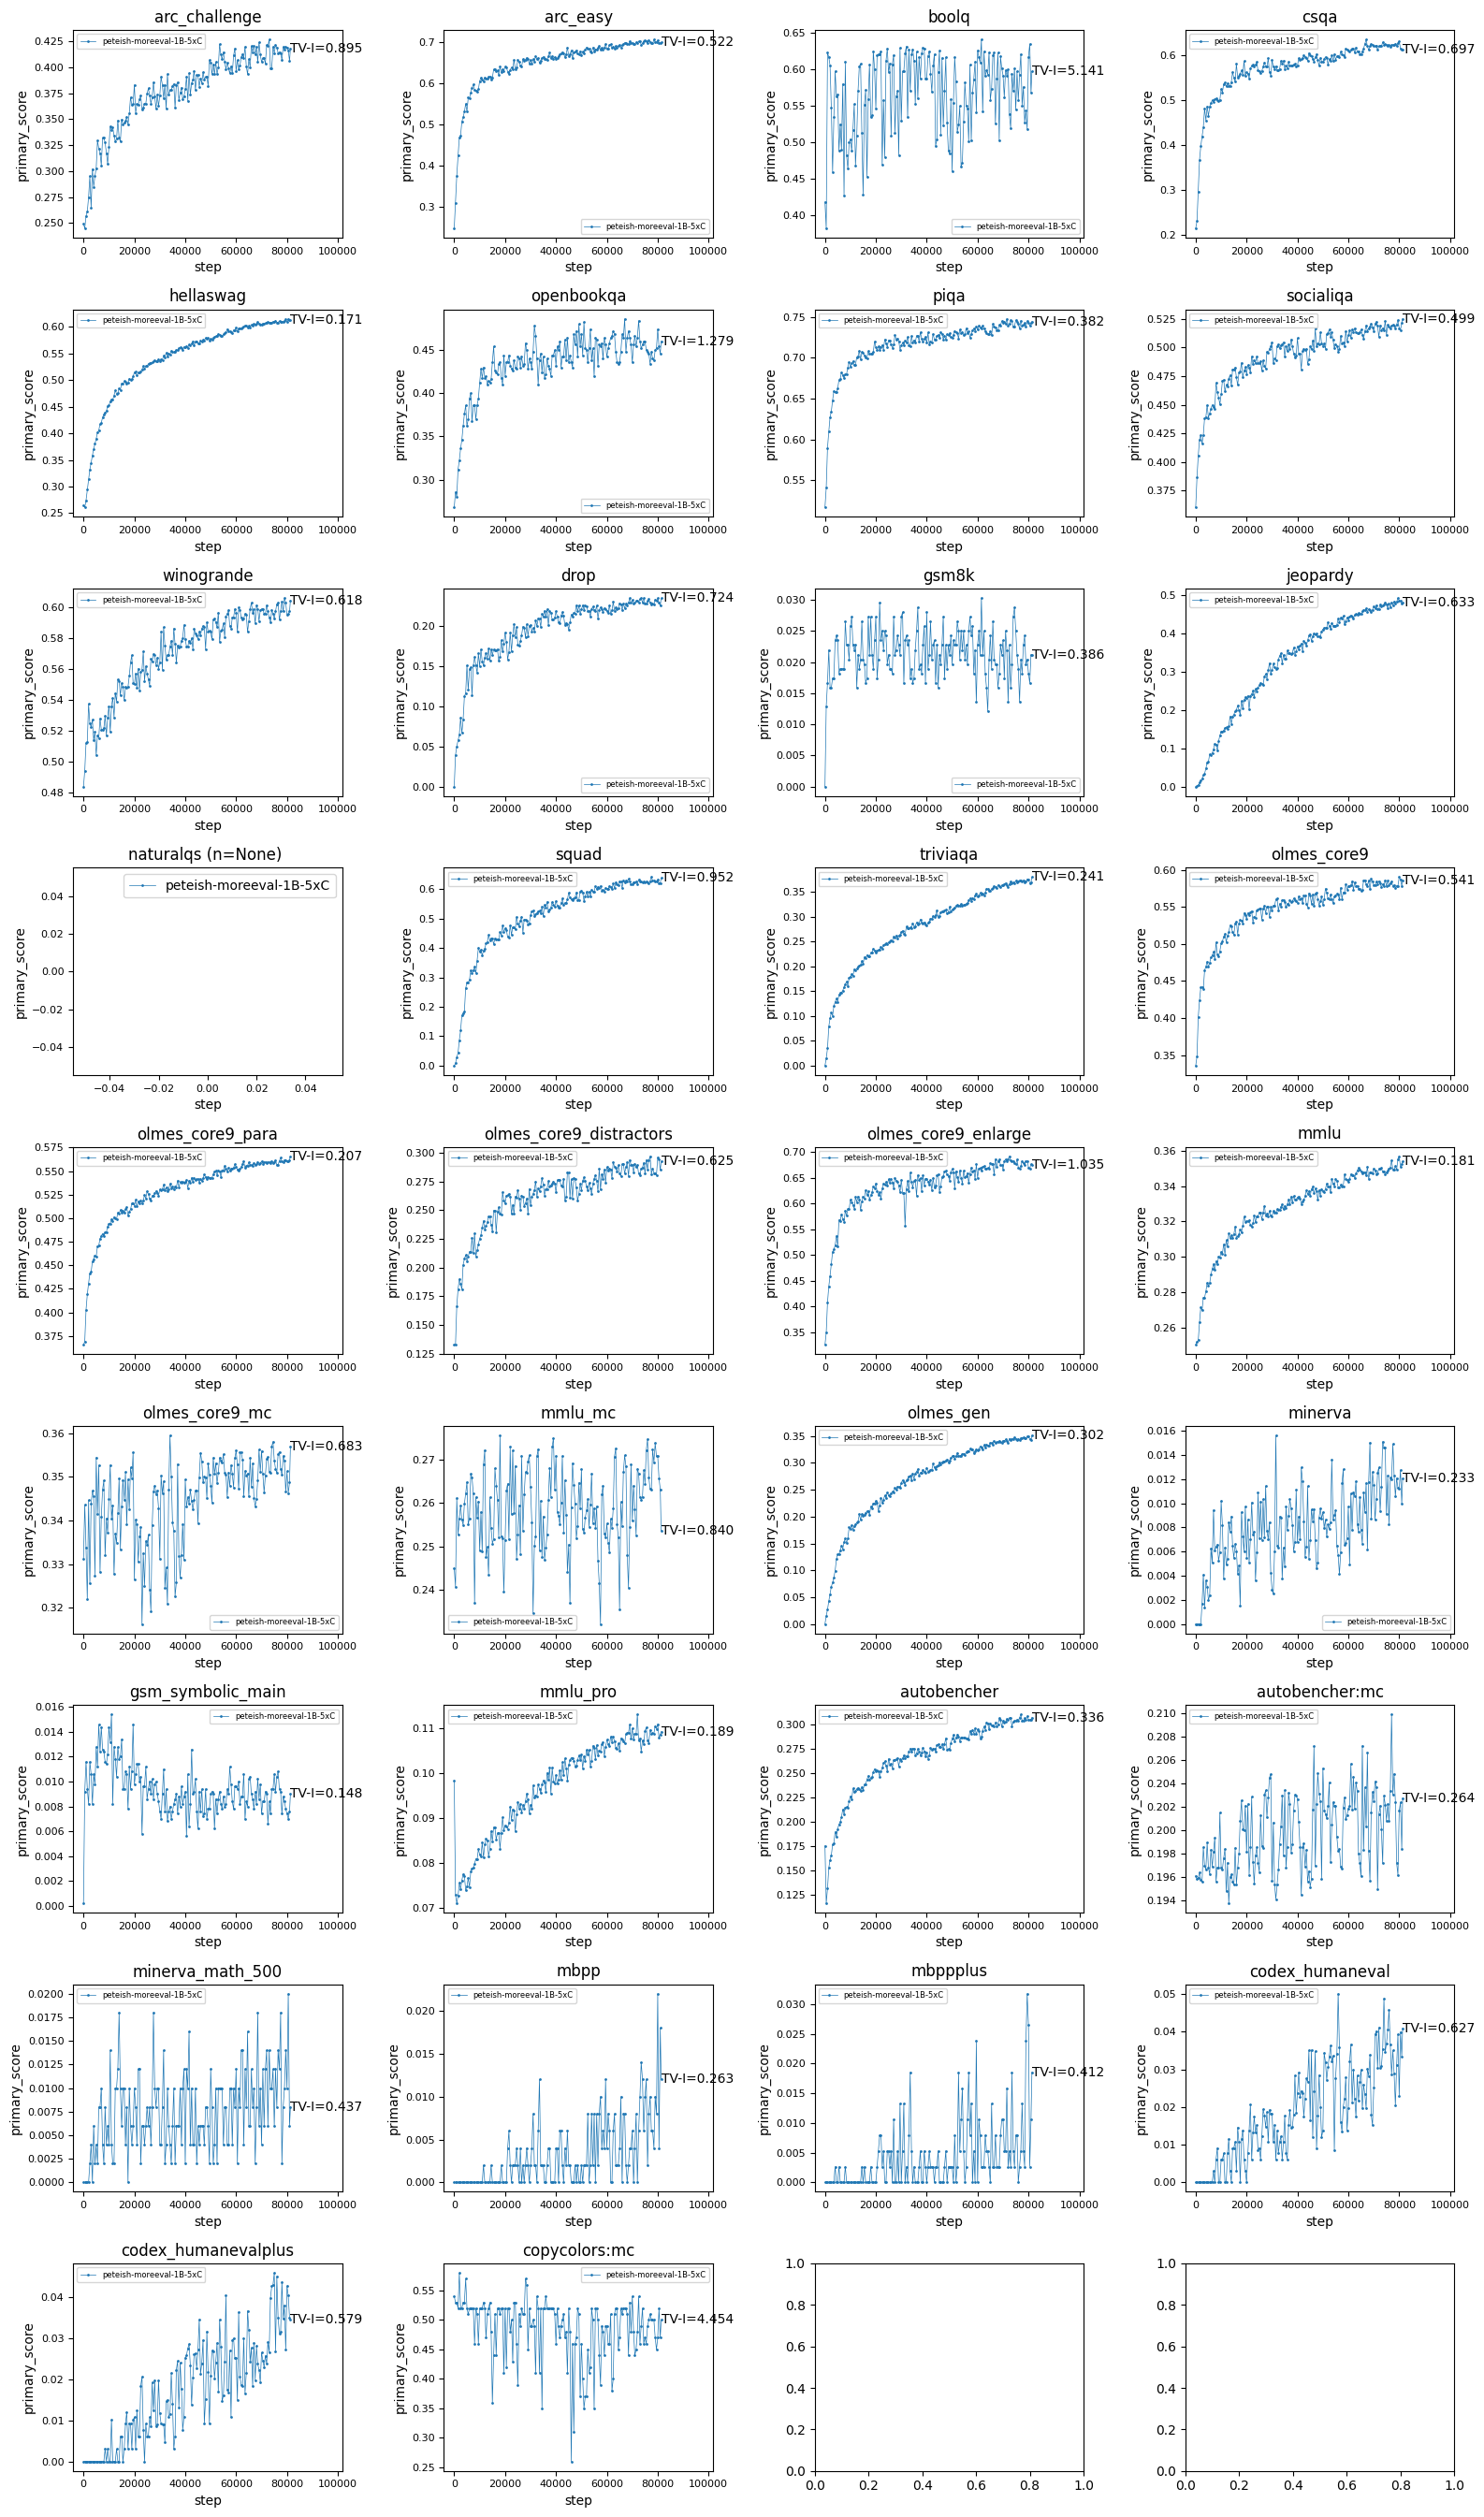

In [19]:
# N_COLS = 3
# N_ROWS = len(selected_tasks) // 3

# fig, axes = plt.subplots(N_COLS, N_ROWS, figsize=(4*N_ROWS, 3*N_COLS), squeeze=False)

# for task in selected_tasks:
#     ax = [axes[1, 1]] if axes is not None else None
#     tv, _ = compute_total_variation(
#         df, models=['peteish-moreeval-1B-5xC'], metric='primary_score', tasks=[task], axes=ax
#     )
#     tv_primary = tv[task]['total_variation'] if not isinstance(task, list) else tv.loc['total_variation']['aggregate']
#     if ax:
#         ax[0].legend(fontsize=6)

#     fig.tight_layout()

import matplotlib.pyplot as plt
import numpy as np
import math

N_COLS = 4
N_ROWS = math.ceil(len(selected_tasks) / N_COLS)

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(4 * N_COLS, 3 * N_ROWS), squeeze=False)

axes = axes.flatten()  # Flatten the 2D array for easy iteration

for i, task in enumerate(selected_tasks):
    try:
        ax = [axes[i]] if i < len(axes) else None  # Ensure ax is valid
        tv, _ = compute_total_variation(
            df, models=['peteish-moreeval-1B-5xC'], metric='primary_score', tasks=[task], axes=ax
        )
        tv_primary = tv[task]['total_variation'] if not isinstance(task, list) else tv.loc['total_variation']['aggregate']
        if ax:
            ax[0].legend(fontsize=6)
        set_title_from_task(ax[0], task)
    except Exception as e:
        pass

fig.tight_layout()
plt.show()

In [473]:
from collections import defaultdict

values = defaultdict(list)

for task in tqdm(selected_tasks):
    result = run_analysis(task)
    for i, val in enumerate(result):
        values[i].append(val)

 15%|█▍        | 5/34 [00:01<00:10,  2.88it/s]

num_instances should be constant across task=hellaswag for task_as_list=['hellaswag']


 35%|███▌      | 12/34 [00:04<00:07,  2.93it/s]

naturalqs failed on ladder fits No scores found for model=peteish-moreeval-190M-0.5xC. Seeing: []
single positional indexer is out-of-bounds


 41%|████      | 14/34 [00:04<00:05,  3.89it/s]

...

 56%|█████▌    | 19/34 [00:06<00:06,  2.37it/s]

num_instances should be constant across task=arc_easy:enlarge for task_as_list=['arc_challenge:enlarge', 'arc_easy:enlarge', 'boolq:enlarge', 'csqa:enlarge', 'hellaswag:enlarge', 'openbookqa:enlarge', 'piqa:enlarge', 'socialiqa:enlarge', 'winogrande:enlarge']


 68%|██████▊   | 23/34 [00:08<00:05,  2.00it/s]

single positional indexer is out-of-bounds


100%|██████████| 34/34 [00:12<00:00,  2.67it/s]


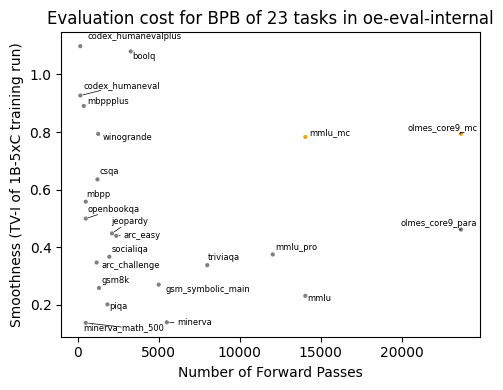

In [476]:
# fig, ax = plt.subplots(figsize=(10, 8))
fig, ax = plt.subplots(figsize=(5, 4))

texts = []

# Collect valid points and tasks
points = []
for i, task in enumerate(selected_tasks[:-1]):
    color = 'grey'
    # if ':mc' in task: continue
    # if ':perturb_cot' in task: continue
    # if ':perturb_rc' in task: continue
    # if ':para' in task: continue
    # if ':distractors' in task: continue
    # if ':enlarge' in task: continue

    # if not any(olm in task for olm in olmes): continue

    task_name = get_title_from_task(task)

    color = 'grey'
    if ':para' in task: color = 'red'
    if ':distractors' in task: color = 'green'
    if ':enlarge' in task: color = 'blue'
    if ':mc' in task or '_mc' in task_name: color = 'orange'

    mse_step_2 = values[0][i]
    rel_error_stacked = values[1][i]
    tv_bpb = values[2][i]
    tv_primary = values[3][i]
    total_cost = values[4][i]
    
    # x, y = mse_step_2, tv_primary
    # x, y = tv_primary, rel_error_stacked
    x, y = total_cost, tv_bpb
    # x, y = total_cost, mse_step_2

    if x != 0 and y != 0 and x != float('nan') and y != float('nan'):
        points.append((x, y, task, color))

# Plot points and create annotations
# points_filtered = [(x, y, t, c) for (x, y, t, c) in points if y < 0.2 and x < 0.06]
# points_filtered = [(x, y, t, c) for (x, y, t, c) in points if y < 1 and x < 0.4]
# points_filtered = [(x, y, t, c) for (x, y, t, c) in points if y < 3 and x < 0.2]
# points_filtered = [(x, y, t, c) for (x, y, t, c) in points if y < 3 and x < 0.4]
# points_filtered = [(x, y, t, c) for (x, y, t, c) in points if y < 3 and x < 0.6]
# points_filtered = [(x, y, t, c) for (x, y, t, c) in points if y < 1.1 and x < 0.6] # mse vs. tv_primary
points_filtered = [(x, y, t, c) for (x, y, t, c) in points if y < 1.1 and x < 30_000] # total_cost vs. tv_primary
# points_filtered = points

xs, ys, tasks, color = zip(*points_filtered)
ax.scatter(xs, ys, s=4, c=color)
texts = [ax.annotate(get_title_from_task(task), (x, y), fontsize=6) for x, y, task, color in points_filtered]

# Adjust text positions to prevent overlap
from adjustText import adjust_text
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

# ax.set_xlim(left=0, right=0.1)
# ax.set_ylim(bottom=0, top=0.8)

# ax.set_xlabel('Predictability (MSE of external models on step 2 fit)')
# ax.set_ylabel('Predictability (MSE of external models on step 2 fit)')
ax.set_xlabel('Number of Forward Passes')
ax.set_ylabel('Smoothness (TV-I of 1B-5xC training run)')
# ax.set_title(f'Properties of {len(texts)} tasks in oe-eval-internal')
# ax.set_title(f'Properties of {len(texts)} tasks in oe-eval-internal')
ax.set_title(f'Evaluation cost for BPB of {len(texts)} tasks in oe-eval-internal')

# from matplotlib.ticker import FuncFormatter
# def percent(x, pos):
#     return f'{100 * x:.0f}%'
# ax.xaxis.set_major_formatter(FuncFormatter(percent))

plt.tight_layout()
plt.show()